In [1]:
import numpy as np
from matplotlib import pyplot as plt

from smt_optim.benchmarks.registry import get_problem

from smt_optim.core import Driver, ObjectiveConfig, ConstraintConfig, DriverConfig, Problem

from smt_optim.surrogate_models.smt import SmtMFCK

from smt_optim.acquisition_strategies.vfpi import VFPI

import scipy.optimize as so




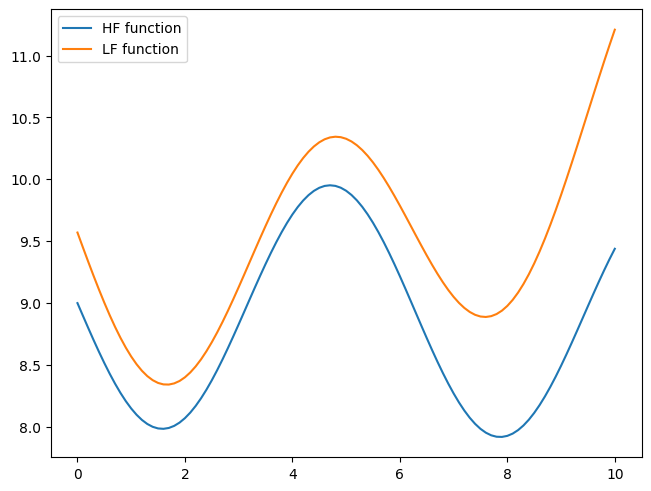

In [2]:
# high-fidelity function
def sasena2002_hf(x):
    return -np.sin(x) - np.exp(x / 100) + 10

# low-fidelity function
def sasena2002_lf(x):
    return sasena2002_hf(x) + 0.3 + 0.03 * (x - 3) ** 2

bounds = np.array([[0, 10]])

x_valid = np.linspace(bounds[:, 0], bounds[:, 1], 101)
y_hf = sasena2002_hf(x_valid)
y_lf = sasena2002_lf(x_valid)

fig, ax = plt.subplots(layout="constrained")
ax.plot(x_valid, y_hf, label="HF function")
ax.plot(x_valid, y_lf, label="LF function")

plt.legend()
plt.show()

In [18]:
obj_config = ObjectiveConfig(
    objective=[sasena2002_lf, sasena2002_hf],   # multi-fidelity functions must be given in sequential order
    type="minimize",
    surrogate=SmtMFCK,
)


prob_definition = Problem(
    obj_configs=[obj_config],
    design_space=bounds,
    costs=[0.2, 1],                 # Set the cost of sampling each level
)


opt_config = DriverConfig(
    max_iter = 1,
    max_budget = 10,                # stopping criterion
    nt_init = 2,
    verbose = True,
    scaling = True,
    seed=42,
)

optimizer = Driver(prob_definition, opt_config, VFPI)

state = optimizer.optimize()

          iter         budget           fmin       fidelity        gp_time       acq_time
             1          3.000    7.99603e+00              1          3.430          2.302


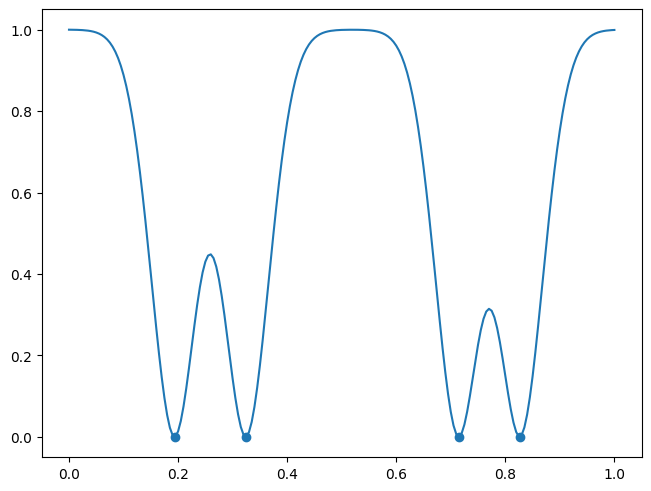

In [24]:
level = 0

x_test = np.linspace(0, 1, 201).reshape(-1, 1)


scaled_data = state.scaled_dataset.export_as_dict()
fid_mask = (scaled_data["fidelity"] == level).ravel()
xt = scaled_data["x"][fid_mask]
yt = np.zeros_like(xt)

density_penalty = optimizer.strategy.sample_density(x_test, level, state.obj_models[0].model)


fig, ax = plt.subplots(layout="constrained")

ax.plot(x_test, density_penalty, label="Penalty")
ax.scatter(xt, yt)


plt.show()
